# Oxford-IIIT Pet — analysis & experiments

Companion to `oxford_pet.ipynb`, which holds the from-scratch U-Net build and the
v1.0 training log. This notebook drives the same model through
`vision_pipeline` and asks the questions the raw training log cannot answer:

1. **Configure** — the two presets side by side
2. **Data** — what the trimap actually contains, and what `boundary` does to it
3. **Model** — widths, shapes, and a strict load of the real v1.0 weights
4. **Train** — a short probe and a small sweep
5. **Evaluate** — the trained v1.0 model taken apart: label-choice inflation,
   threshold calibration, TTA, native-resolution scoring, and the worst cases
6. **Benchmark** — where this lands against the reference bands

Section 5 is the substance. Everything in it runs against
`checkpoints/20260821-170419_Unet_simple_best.pt` — the actual 31.04M-parameter
model that scored 0.9367 Dice, not a re-run.

In [ ]:
%load_ext autoreload
%autoreload 2

import math
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from vision_pipeline import (
    Config, build_loaders, evaluate, get_device, segmentation, set_seed, setup, train,
)
from vision_pipeline.data import normalization, num_classes, task
from vision_pipeline.data.oxford_pet import (
    TRIMAP_BOUNDARY, TRIMAP_PET, TRIMAP_BACKGROUND, build_eval_transform,
)
from vision_pipeline.inference import Predictor
from vision_pipeline.models import build_unet, count_parameters
from vision_pipeline.segmentation import IGNORE_INDEX

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
device = get_device()
print(device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

cuda NVIDIA GeForce RTX 5080


## 1. Configure

In [2]:
# Two presets: the reproduction recipe and the recommended one. The differences
# are exactly the levers the v1.0 post-mortem called for.
v1 = Config.preset("oxford_pet_v1")
v2 = Config.preset("oxford_pet")

rows = []
for field, a, b in [
    ("arch",           v1.model.arch,          v2.model.arch),
    ("up_mode",        v1.model.up_mode,       v2.model.up_mode),
    ("boundary",       v1.data.boundary,       v2.data.boundary),
    ("normalize",      v1.data.normalize,      v2.data.normalize),
    ("presize",        v1.data.presize,        v2.data.presize),
    ("crop_scale",     v1.data.crop_scale,     v2.data.crop_scale),
    ("rotation_deg",   v1.data.rotation_degrees, v2.data.rotation_degrees),
    ("color_jitter",   v1.data.color_jitter,   v2.data.color_jitter),
    ("criterion",      v1.train.criterion,     v2.train.criterion),
    ("dice_weight",    v1.train.dice_weight,   v2.train.dice_weight),
    ("epochs",         v1.train.epochs,        v2.train.epochs),
]:
    flag = "  <-- differs" if a != b else ""
    rows.append(f"{field:14s} {str(a):18s} {str(b):18s}{flag}")

print(f"{'':14s} {'oxford_pet_v1':18s} {'oxford_pet':18s}")
print("\n".join(rows))
print(f"\ntask={task(v2.data)}  head channels required by the data={num_classes(v2.data)}")

               oxford_pet_v1      oxford_pet        
arch           unet               unet              
up_mode        transpose          bilinear            <-- differs
boundary       foreground         ignore              <-- differs
normalize      False              True                <-- differs
presize        144                None                <-- differs
crop_scale     (0.08, 1.0)        (0.7, 1.0)          <-- differs
rotation_deg   0.0                10.0                <-- differs
color_jitter   0.0                0.2                 <-- differs
criterion      bce                bce_dice            <-- differs
dice_weight    0.5                0.5               
epochs         100                60                  <-- differs

task=segmentation  head channels required by the data=1


## 2. Data

In [3]:
set_seed(v1.data.seed)
# Small eval subset so the loaders build fast; the full test split is used in S5.
probe_data = replace(v2.data, eval_train_size=512)
loaders = build_loaders(probe_data)
print(loaders.summary())

images, masks = next(iter(loaders.train))
print(f"\nimages {tuple(images.shape)} {images.dtype}  range [{images.min():.2f}, {images.max():.2f}]")
print(f"masks  {tuple(masks.shape)} {masks.dtype}  values {torch.unique(masks).tolist()}")
print("255 = ignore: the trimap's 'not classified' band, dropped from loss and metric")

Training images:          3,680
Held-out images:          3,669
Evaluation subset images: 512
Number of classes:        2



images (32, 3, 128, 128) torch.float32  range [-2.12, 2.64]
masks  (32, 1, 128, 128) torch.int64  values [0, 1, 255]
255 = ignore: the trimap's 'not classified' band, dropped from loss and metric


### What the trimap actually contains

The single most important number for reading any Oxford-Pet segmentation score:
how big the boundary band is. `boundary="foreground"` (the v1.0 choice) folds it
into the pet; `boundary="ignore"` drops it.

In [4]:
# Composition over the FULL test split, at native resolution — no resizing, so
# these are the annotators' own proportions.
from torchvision.datasets import OxfordIIITPet
from PIL import Image

raw = OxfordIIITPet(root=v2.data.root, split="test", target_types="segmentation", download=False)
pet = bg = boundary = total = 0
per_image_boundary = []
for _, target in raw:
    a = np.array(target)
    p, b, d = (a == TRIMAP_PET).sum(), (a == TRIMAP_BACKGROUND).sum(), (a == TRIMAP_BOUNDARY).sum()
    pet += p; bg += b; boundary += d; total += a.size
    per_image_boundary.append(d / a.size)

print(f"test images: {len(raw):,}")
print(f"  pet      (trimap 1) {pet/total:7.2%}")
print(f"  backgnd  (trimap 2) {bg/total:7.2%}")
print(f"  boundary (trimap 3) {boundary/total:7.2%}   <-- the void band")
print()
print(f"boundary as a share of the pet-plus-boundary target: {boundary/(pet+boundary):.2%}")
print(f"so under boundary='foreground', {boundary/(pet+boundary):.1%} of every positive")
print("target is a region the annotators explicitly declined to label.")

test images: 3,669
  pet      (trimap 1)  29.85%
  backgnd  (trimap 2)  57.96%
  boundary (trimap 3)  12.18%   <-- the void band

boundary as a share of the pet-plus-boundary target: 28.98%
so under boundary='foreground', 29.0% of every positive
target is a region the annotators explicitly declined to label.


In [5]:
# Trivial baselines under each label choice — the floor any real score must clear.
fg_foreground = (pet + boundary) / total   # boundary counted as pet
fg_ignore = pet / (pet + bg)               # boundary dropped entirely

print(f"{'label choice':22s} {'fg fraction':>12s} {'all-bg pixacc':>14s} {'all-fg dice':>12s}")
for name, frac in (("boundary=foreground", fg_foreground), ("boundary=ignore", fg_ignore)):
    # all-foreground Dice = 2f/(1+f) with f the foreground fraction; IoU = f.
    print(f"{name:22s} {frac:12.3f} {1 - frac:14.3f} {2 * frac / (1 + frac):12.3f}")
print("\nPixel accuracy is a weak metric here: predicting all-background already")
print(f"scores {1 - fg_foreground:.3f} under the v1.0 label choice.")

label choice            fg fraction  all-bg pixacc  all-fg dice
boundary=foreground           0.420          0.580        0.592
boundary=ignore               0.340          0.660        0.507

Pixel accuracy is a weak metric here: predicting all-background already
scores 0.580 under the v1.0 label choice.


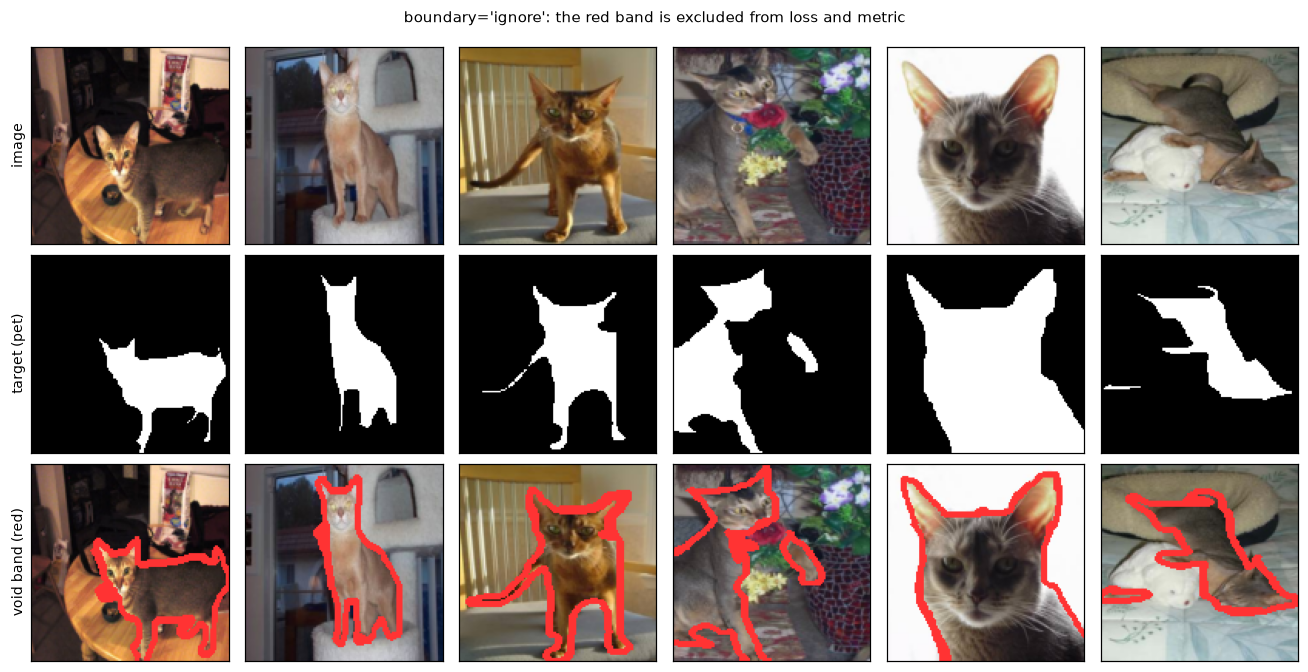

In [6]:
# Preview: image / ground truth / the void band, for the two boundary modes.
mean, std = normalization(v2.data)
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)

show_cfg = replace(v2.data, boundary="ignore")
show_loader = build_loaders(replace(show_cfg, eval_train_size=8)).val
imgs, msks = next(iter(show_loader))

n = 6
fig, axes = plt.subplots(3, n, figsize=(2.0 * n, 6.2))
for i in range(n):
    img = (imgs[i] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    m = msks[i, 0].numpy()
    axes[0, i].imshow(img)
    axes[1, i].imshow(np.where(m == IGNORE_INDEX, 0, m), cmap="gray", vmin=0, vmax=1)
    # Red where ignored, so the width of the discarded band is visible.
    overlay = img.copy()
    overlay[m == IGNORE_INDEX] = [1.0, 0.2, 0.2]
    axes[2, i].imshow(overlay)
    for r in range(3):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([]); axes[r, i].grid(False)
for r, label in enumerate(["image", "target (pet)", "void band (red)"]):
    axes[r, 0].set_ylabel(label, fontsize=9)
fig.suptitle("boundary='ignore': the red band is excluded from loss and metric", fontsize=10)
plt.tight_layout(); plt.show()

## 3. Model

In [7]:
# Width/depth presets, and what up_mode costs.
print(f"{'arch':14s} {'up_mode':11s} {'params (M)':>11s}")
for arch in ("unet", "unet_small", "unet_tiny"):
    for up in ("transpose", "bilinear"):
        m = build_unet(arch=arch, num_classes=1, up_mode=up)
        print(f"{arch:14s} {up:11s} {count_parameters(m)/1e6:11.3f}")
print()
print("bilinear costs MORE, not less: a 3x3 conv after the upsample is 2.25x a")
print("2x2 transposed conv. The reason to use it is checkerboard-free masks.")

arch           up_mode      params (M)
unet           transpose        31.038


unet           bilinear         34.520
unet_small     transpose         7.763
unet_small     bilinear          8.634
unet_tiny      transpose         0.483
unet_tiny      bilinear          0.537

bilinear costs MORE, not less: a 3x3 conv after the upsample is 2.25x a
2x2 transposed conv. The reason to use it is checkerboard-free masks.


In [8]:
set_seed(v1.train.seed)
unet = build_unet(arch="unet", num_classes=1, up_mode="transpose").to(device)
unet = unet.to(memory_format=torch.channels_last)

with torch.inference_mode():
    out = unet(images[:4].to(device).contiguous(memory_format=torch.channels_last))
print(f"in  {tuple(images[:4].shape)}")
print(f"out {tuple(out.shape)}  <- one logit per pixel, spatial size preserved")
print(f"size_divisor = {unet.size_divisor} (inputs must be a multiple of 2**depth)")

try:
    build_unet(arch="unet", num_classes=1, image_size=100)
except ValueError as exc:
    print(f"\nguard: {exc}")

in  (4, 3, 128, 128)
out (4, 1, 128, 128)  <- one logit per pixel, spatial size preserved
size_divisor = 16 (inputs must be a multiple of 2**depth)

guard: image_size 100 is not divisible by 2**depth = 16; use a multiple of 16 or reduce depth.


### Loading the real v1.0 weights

The refactor preserved the module structure, so the checkpoint the notebook wrote
loads into `vision_pipeline`'s `Unet` under `strict=True`. That is the check that
the analysis below is measuring the same model the log describes.

In [9]:
CKPT = "checkpoints/20260821-170419_Unet_simple_best.pt"
ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
print("recorded in the checkpoint:", {k: round(v, 4) if isinstance(v, float) else v
      for k, v in ckpt.items() if k in ("epoch", "test_dice", "test_iou", "test_pixel_acc")})

v1_model = build_unet(arch="unet", num_classes=1, up_mode="transpose")
v1_model.load_state_dict(ckpt["model_state"])   # strict — raises on any mismatch
v1_model = v1_model.to(device).to(memory_format=torch.channels_last).eval()
print(f"\nstrict load OK — {count_parameters(v1_model)/1e6:.3f}M parameters")

recorded in the checkpoint: {'epoch': 85, 'test_dice': 0.9367, 'test_iou': 0.8964, 'test_pixel_acc': 0.9538}



strict load OK — 31.038M parameters


## 4. Train

A short probe on `unet_tiny` — enough to confirm the loop, the curves, and that
Dice/IoU move together. Full runs belong on the CLI, which survives the kernel:

    python -m vision_pipeline.cli train --preset oxford_pet
    python -m vision_pipeline.cli train --preset oxford_pet_v1

In [10]:
probe = replace(
    v2,
    data=replace(v2.data, eval_train_size=384, batch_size=16, eval_batch_size=16),
    model=replace(v2.model, arch="unet_tiny"),
    train=replace(v2.train, epochs=4, warmup_epochs=1, run_name="analysis_probe"),
)
model, probe_loaders, opt, sched, crit, dev, resume = setup(probe)
history = train(model, probe_loaders, probe, optimizer=opt, scheduler=sched,
                criterion=crit, device=dev, **resume)

cuda NVIDIA GeForce RTX 5080
0.54M parameters


Epoch [1/4], Loss: 0.8708, Train Dice: 0.7109, Test Dice: 0.7142, Test IoU: 0.5931, LR: 0.001000, 10.3s


Epoch [2/4], Loss: 0.6105, Train Dice: 0.7920, Test Dice: 0.7980, Test IoU: 0.6898, LR: 0.000750, 6.7s


Epoch [3/4], Loss: 0.4654, Train Dice: 0.8008, Test Dice: 0.8040, Test IoU: 0.7015, LR: 0.000250, 6.7s


Epoch [4/4], Loss: 0.4000, Train Dice: 0.8351, Test Dice: 0.8466, Test IoU: 0.7606, LR: 0.000000, 6.8s


Best test dice: 0.8466 (checkpoints/analysis_probe_best.pt)


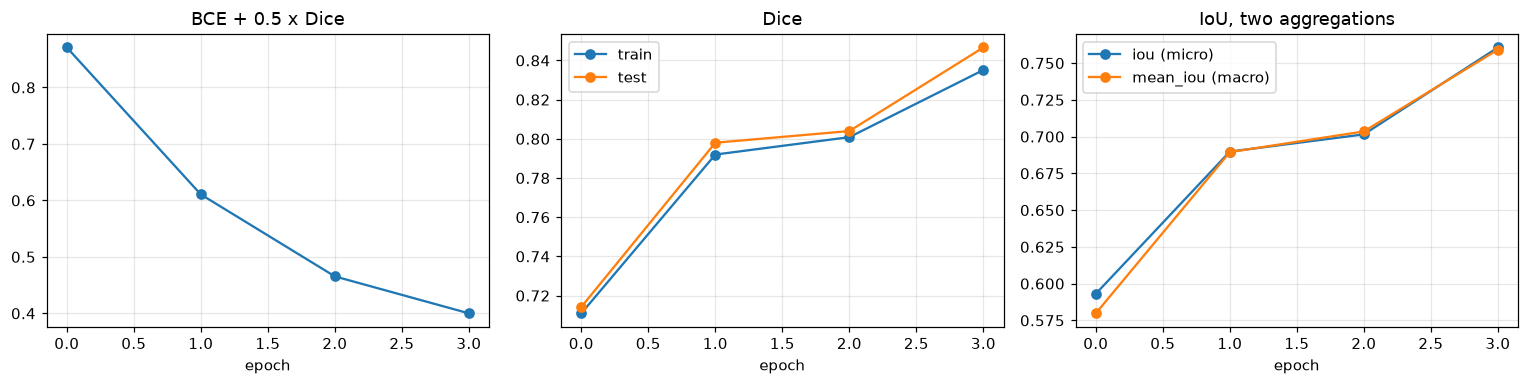

,epoch,loss,train_dice,test_dice,gap,lr,epoch_time,test_pixel_acc,test_iou,test_mean_iou
0,0,0.870786,0.710944,0.714187,-0.003242,0.00100,10.264122,0.812309,0.593082,0.579783
1,1,0.610537,0.791977,0.798005,-0.006028,0.00075,6.681951,0.874711,0.689809,0.689417
2,2,0.465425,0.800846,0.803965,-0.003119,0.00025,6.715087,0.865017,0.701506,0.703520
3,3,0.400004,0.835122,0.846618,-0.011496,0.00000,6.764928,0.905603,0.760625,0.759140


In [11]:
frame = history.to_frame()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].plot(frame["epoch"], frame["loss"], marker="o")
axes[0].set_title("BCE + 0.5 x Dice"); axes[0].set_xlabel("epoch")

axes[1].plot(frame["epoch"], frame["train_dice"], marker="o", label="train")
axes[1].plot(frame["epoch"], frame["test_dice"], marker="o", label="test")
axes[1].set_title("Dice"); axes[1].set_xlabel("epoch"); axes[1].legend()

axes[2].plot(frame["epoch"], frame["test_iou"], marker="o", label="iou (micro)")
axes[2].plot(frame["epoch"], frame["test_mean_iou"], marker="o", label="mean_iou (macro)")
axes[2].set_title("IoU, two aggregations"); axes[2].set_xlabel("epoch"); axes[2].legend()

plt.tight_layout(); plt.show()
frame

### Parameter sweep

The one comparison worth making cheaply: does the Dice term in the loss earn its
place? `dice_weight=0` is plain BCE (the v1.0 loss); 0.5 is the recommended mix.

In [12]:
sweep = {
    "bce only  (dice_w=0)":   replace(probe.train, criterion="bce", run_name="sweep_bce"),
    "bce+dice  (dice_w=0.5)": replace(probe.train, criterion="bce_dice", dice_weight=0.5,
                                      run_name="sweep_bce_dice"),
}

results = {}
for name, tcfg in sweep.items():
    cfg_i = replace(probe, train=tcfg)
    m, ld, o, s, c, d, r = setup(cfg_i)
    print(f"\n--- {name} ---")
    results[name] = train(m, ld, cfg_i, optimizer=o, scheduler=s, criterion=c,
                          device=d, verbose=True, **r)

cuda NVIDIA GeForce RTX 5080
0.54M parameters

--- bce only  (dice_w=0) ---


Epoch [1/4], Loss: 0.6429, Train Dice: 0.6981, Test Dice: 0.7023, Test IoU: 0.5806, LR: 0.001000, 7.1s


Epoch [2/4], Loss: 0.4358, Train Dice: 0.7700, Test Dice: 0.7765, Test IoU: 0.6641, LR: 0.000750, 6.6s


Epoch [3/4], Loss: 0.3377, Train Dice: 0.7697, Test Dice: 0.7740, Test IoU: 0.6632, LR: 0.000250, 6.6s


Epoch [4/4], Loss: 0.2922, Train Dice: 0.8341, Test Dice: 0.8444, Test IoU: 0.7588, LR: 0.000000, 6.6s


...

Epoch [1/4], Loss: 0.8704, Train Dice: 0.7118, Test Dice: 0.7149, Test IoU: 0.5938, LR: 0.001000, 6.9s


Epoch [2/4], Loss: 0.6097, Train Dice: 0.7895, Test Dice: 0.7879, Test IoU: 0.6747, LR: 0.000750, 6.6s


Epoch [3/4], Loss: 0.4648, Train Dice: 0.7995, Test Dice: 0.8039, Test IoU: 0.7016, LR: 0.000250, 6.6s


Epoch [4/4], Loss: 0.3998, Train Dice: 0.8383, Test Dice: 0.8495, Test IoU: 0.7641, LR: 0.000000, 6.6s


Best test dice: 0.8495 (checkpoints/sweep_bce_dice_best.pt)


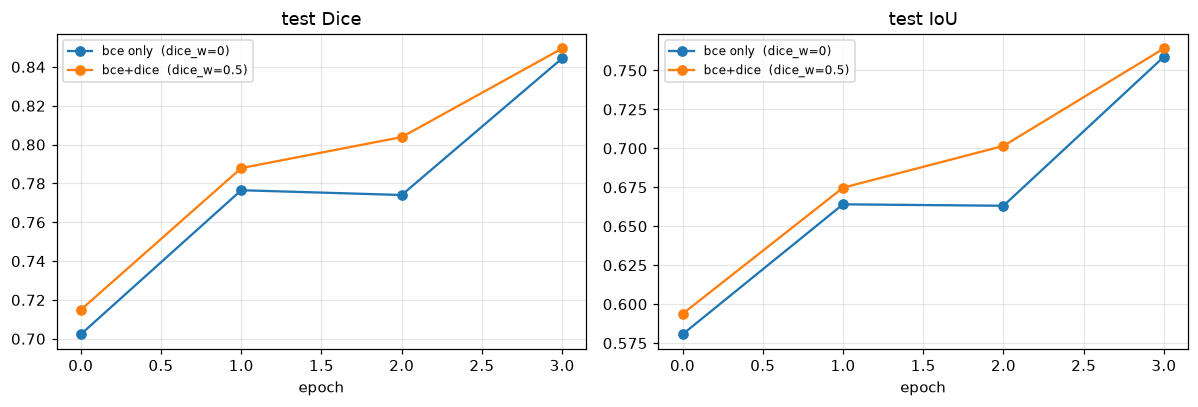

bce only  (dice_w=0)     best Dice 0.8444 @ epoch 3
bce+dice  (dice_w=0.5)   best Dice 0.8495 @ epoch 3

Four epochs is far too short to settle this — it shows the mechanism works,
not which loss wins. Run both presets to 60 epochs on the CLI for that.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, h in results.items():
    axes[0].plot(h.epoch, h.test_acc, marker="o", label=name)
    axes[1].plot(h.epoch, h.series("iou"), marker="o", label=name)
axes[0].set_title("test Dice"); axes[1].set_title("test IoU")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for name, h in results.items():
    print(f"{name:24s} best Dice {h.best_score:.4f} @ epoch {h.best_epoch}")
print("\nFour epochs is far too short to settle this — it shows the mechanism works,")
print("not which loss wins. Run both presets to 60 epochs on the CLI for that.")

## 5. Evaluate the trained v1.0 model

Everything below runs on the real 31.04M model that scored 0.9367. One forward
pass over the 3,669-image test split is cached, and every question is answered
from that cache — so the threshold sweep, the label-choice comparison and the
worst-case gallery cost nothing extra.

**The v1.0 model was trained on unnormalized `[0, 1]` input**, so the eval
transform has to match (`normalize=False`). Feeding it mean/std-normalized pixels
would be measuring a different function.

In [14]:
# A loader that yields the RAW trimap (boundary="class" maps 1,2,3 -> 0,1,2), so
# any boundary mode can be derived in numpy from a single cached pass.
cache_cfg = replace(
    v1.data,                       # v1.0 protocol: normalize=False, 128px
    boundary="class",
    eval_batch_size=16,            # small: the GPU is shared
    eval_train_size=16,
    num_workers=4, eval_num_workers=4,
)
cache_loader = build_loaders(cache_cfg).val
print(f"cache pass over {len(cache_loader.dataset):,} test images, "
      f"normalize={cache_cfg.normalize}, image_size={cache_cfg.image_size}")

probs_all, trimap_all = [], []
with torch.inference_mode():
    for x, y in cache_loader:
        x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
            logits = v1_model(x)
        probs_all.append(torch.sigmoid(logits.float()).squeeze(1).half().cpu())
        trimap_all.append(y.squeeze(1).to(torch.uint8))

probs = torch.cat(probs_all)      # (N, 128, 128) float16, P(pet)
trimap = torch.cat(trimap_all)    # (N, 128, 128) uint8: 0=pet, 1=background, 2=boundary
del probs_all, trimap_all
print(f"cached probs {tuple(probs.shape)} {probs.dtype} "
      f"({probs.element_size() * probs.nelement() / 1e6:.0f} MB)")

cache pass over 3,669 test images, normalize=False, image_size=128


cached probs (3669, 128, 128) torch.float16 (120 MB)


In [15]:
def score(prob, target, ignore=None, threshold=0.5, eps=1e-7):
    """Dice/IoU/pixel-acc from cached probabilities. `ignore` masks pixels out."""
    pred = (prob.float() > threshold)
    tgt = target.bool()
    if ignore is not None:
        keep = ~ignore
        pred = pred & keep
        tgt = tgt & keep
    else:
        keep = torch.ones_like(tgt)

    dims = (1, 2)
    inter = (pred & tgt).sum(dims).float()
    psum = pred.sum(dims).float()
    tsum = tgt.sum(dims).float()
    union = psum + tsum - inter

    return {
        "pixel_acc": (((pred == tgt) & keep).sum().float() / keep.sum()).item(),
        "dice": ((2 * inter + eps) / (psum + tsum + eps)).mean().item(),
        "iou": (inter.sum() / union.sum().clamp(min=eps)).item(),
        "mean_iou": ((inter + eps) / (union + eps)).mean().item(),
    }

is_pet, is_bg, is_boundary = trimap == 0, trimap == 1, trimap == 2

# v1.0 protocol: boundary counted as pet, nothing ignored.
v1_protocol = score(probs, is_pet | is_boundary)
print("v1.0 protocol (boundary='foreground'):")
for k, val in v1_protocol.items():
    print(f"  {k:10s} {val:.4f}")
print(f"\nlogged in the checkpoint: dice {ckpt['test_dice']:.4f}  iou {ckpt['test_iou']:.4f}  "
      f"pixel_acc {ckpt['test_pixel_acc']:.4f}")

v1.0 protocol (boundary='foreground'):
  pixel_acc  0.9538
  dice       0.9367
  iou        0.8964
  mean_iou   0.8888

logged in the checkpoint: dice 0.9367  iou 0.8964  pixel_acc 0.9538


### 5a. What the label choice was worth

The same weights, the same predictions — only the scoring target changes.

**This reverses the prediction made in the v1.0 post-mortem.** That note argued
that folding the void band into the positive target *inflates* Dice by 2-4 points,
on the reasoning that a dilated blob is an easier shape to hit. Measured, the
effect goes the other way and is small: `boundary='ignore'` scores **higher**.

The reason is that the void band is the *hard* region, not a free one. The model
was trained on the dilated target, so it predicts the dilated blob; excluding the
band from scoring removes the pixels it is worst at. Which effect dominates was
an empirical question, and the guess was wrong.

The large number in the table below is the third row. `boundary='background'` —
scoring against the animal's actual outline — costs **15.6 points**. The model
has learned to predict pet-plus-band, because that is what it was trained on, and
it genuinely does not delineate the pet. *That* is the caveat that matters when
comparing this run to a paper.

In [16]:
comparison = {
    "boundary='foreground' (v1.0)": score(probs, is_pet | is_boundary),
    "boundary='ignore' (honest)":   score(probs, is_pet, ignore=is_boundary),
    "boundary='background' (strict)": score(probs, is_pet),
}
print(f"{'protocol':32s} {'dice':>8s} {'iou':>8s} {'mean_iou':>9s} {'pix_acc':>8s}")
for name, m in comparison.items():
    print(f"{name:32s} {m['dice']:8.4f} {m['iou']:8.4f} {m['mean_iou']:9.4f} {m['pixel_acc']:8.4f}")

delta = comparison["boundary='foreground' (v1.0)"]["dice"] - comparison["boundary='ignore' (honest)"]["dice"]
print(f"\nfolding the void band into the target is worth {delta:+.4f} Dice "
      f"({delta * 100:+.1f} points).")

protocol                             dice      iou  mean_iou  pix_acc
boundary='foreground' (v1.0)       0.9367   0.8964    0.8888   0.9538
boundary='ignore' (honest)         0.9418   0.9110    0.9016   0.9672
boundary='background' (strict)     0.7801   0.6872    0.6520   0.8659

folding the void band into the target is worth -0.0052 Dice (-0.5 points).


### 5b. Is 0.5 the right threshold?

The training loop hard-codes 0.5. Whether that is optimal is worth checking
separately for each scoring protocol — and the two answers turn out to say
different things.

**And a leakage caveat on the result below.** The threshold is being swept *on the
test split*, and the best value reported. That is test-set fitting: 0.9628 is not a
number you could have claimed in advance, and it is not reportable as a test score.
Oxford-IIIT Pet ships only `trainval` and `test`, so doing this properly means
carving a validation split out of `trainval`, tuning the threshold there, and then
applying that fixed threshold once to `test`. Treat the sweep as a diagnostic of
calibration — which is what it is used for here — not as a result.


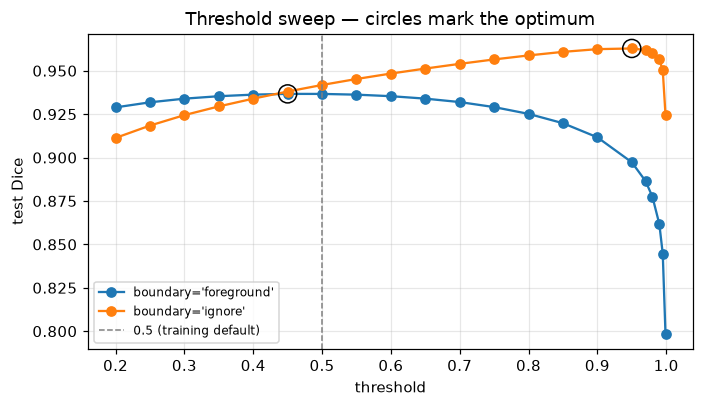

boundary='foreground': best Dice 0.9367 at threshold 0.450 (+0.0000 over 0.5)
boundary='ignore': best Dice 0.9628 at threshold 0.950 (+0.0210 over 0.5)

Read: under the protocol the model was TRAINED for ('foreground'), 0.5 is
already optimal -- so the model is well calibrated, and there is no free
Dice sitting on the table. The large apparent gain under 'ignore' is the
threshold absorbing a train/test protocol MISMATCH: it is peeling off a band
the model was explicitly taught to predict. That is worth doing if you must
report 'ignore' numbers from these weights, but it is a patch, not a lever --
the principled fix is to TRAIN with boundary='ignore', which the oxford_pet
preset now does by default.


In [17]:
# Finer grid near 1.0: the coarse sweep put the 'ignore' optimum at the edge, so
# the grid itself was the binding constraint rather than the model.
thresholds = np.concatenate([np.arange(0.20, 0.95, 0.05),
                             [0.95, 0.97, 0.98, 0.99, 0.995, 0.999]])
curves = {"foreground": [], "ignore": []}
for t in thresholds:
    curves["foreground"].append(score(probs, is_pet | is_boundary, threshold=t)["dice"])
    curves["ignore"].append(score(probs, is_pet, ignore=is_boundary, threshold=t)["dice"])

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for name, ys in curves.items():
    ax.plot(thresholds, ys, marker="o", label=f"boundary='{name}'")
    best = int(np.argmax(ys))
    ax.scatter([thresholds[best]], [ys[best]], s=140, facecolors="none", edgecolors="k", zorder=5)
ax.axvline(0.5, ls="--", c="grey", lw=1, label="0.5 (training default)")
ax.set_xlabel("threshold"); ax.set_ylabel("test Dice"); ax.legend(fontsize=8)
ax.set_title("Threshold sweep — circles mark the optimum")
plt.tight_layout(); plt.show()

half = int(np.argmin(np.abs(thresholds - 0.5)))
for name, ys in curves.items():
    best = int(np.argmax(ys))
    print(f"boundary='{name}': best Dice {ys[best]:.4f} at threshold {thresholds[best]:.3f} "
          f"(+{ys[best] - ys[half]:.4f} over 0.5)")

print()
print("Read: under the protocol the model was TRAINED for ('foreground'), 0.5 is")
print("already optimal -- so the model is well calibrated, and there is no free")
print("Dice sitting on the table. The large apparent gain under 'ignore' is the")
print("threshold absorbing a train/test protocol MISMATCH: it is peeling off a band")
print("the model was explicitly taught to predict. That is worth doing if you must")
print("report 'ignore' numbers from these weights, but it is a patch, not a lever --")
print("the principled fix is to TRAIN with boundary='ignore', which the oxford_pet")
print("preset now does by default.")

### 5c. Test-time augmentation

Averaging the logits with the horizontally flipped input. Costs one extra forward
pass at inference and no retraining.

In [18]:
tta_probs = []
with torch.inference_mode():
    for x, _ in cache_loader:
        x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
            logits = v1_model(x)
            flipped = torch.flip(v1_model(torch.flip(x, dims=[-1])), dims=[-1])
        tta_probs.append(torch.sigmoid(((logits + flipped) / 2).float()).squeeze(1).half().cpu())
tta_probs = torch.cat(tta_probs)

for label, p in (("no TTA", probs), ("hflip TTA", tta_probs)):
    m = score(p, is_pet, ignore=is_boundary)
    print(f"{label:11s} dice {m['dice']:.4f}  iou {m['iou']:.4f}")
gain = score(tta_probs, is_pet, ignore=is_boundary)["dice"] - score(probs, is_pet, ignore=is_boundary)["dice"]
print(f"\nTTA gain: {gain:+.4f} Dice")

no TTA      dice 0.9418  iou 0.9110


hflip TTA   dice 0.9451  iou 0.9154



TTA gain: +0.0033 Dice


### 5d. Scoring at native resolution

Caveat 2 from the v1.0 post-mortem: the logged number is measured at 128x128,
while published figures upsample the logits to the original mask size.

Worth checking rather than asserting — and it turns out to be **immaterial here**,
a difference of under 0.001 Dice. Upsampling the logits recovers the boundary
detail well enough that where you threshold does not matter. That caveat can be
dropped; raising `image_size` is still a lever for the *model*, but not for the
honesty of the *measurement*.

In [19]:
# Native-resolution scoring on a subset — this loop cannot batch (every image has
# a different size), so it is slower per image than the cached pass.
SUBSET = 400
raw_eval = OxfordIIITPet(root=v1.data.root, split="test", target_types="segmentation", download=False)

acc = {k: [] for k in ("dice_native", "dice_128")}
with torch.inference_mode():
    for i in range(SUBSET):
        image, target = raw_eval[i]
        tri_native = torch.from_numpy(np.array(target)).long()          # H, W in {1,2,3}
        h, w = tri_native.shape

        x = torch.from_numpy(np.array(image.convert("RGB"))).permute(2, 0, 1).float() / 255
        x128 = F.interpolate(x[None], size=(128, 128), mode="bilinear",
                             align_corners=False, antialias=True)
        x128 = x128.to(device).contiguous(memory_format=torch.channels_last)

        with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
            logits = v1_model(x128).float()

        # Native: upsample LOGITS then threshold. 128px: threshold at model res.
        up = F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)
        pred_native = (torch.sigmoid(up)[0, 0].cpu() > 0.5)

        tri_128 = F.interpolate(tri_native[None, None].float(), size=(128, 128),
                                mode="nearest")[0, 0].long()
        pred_128 = (torch.sigmoid(logits)[0, 0].cpu() > 0.5)

        for key, pred, tri in (("dice_native", pred_native, tri_native),
                               ("dice_128", pred_128, tri_128)):
            keep = tri != 3
            p = pred & keep
            t = (tri == 1) & keep
            inter = (p & t).sum().float()
            acc[key].append((2 * inter / (p.sum() + t.sum()).clamp(min=1)).item())

print(f"subset of {SUBSET} test images, boundary='ignore' in both columns")
print(f"  scored at 128x128        dice {np.mean(acc['dice_128']):.4f}")
print(f"  scored at native res     dice {np.mean(acc['dice_native']):.4f}")
print(f"  difference               {np.mean(acc['dice_native']) - np.mean(acc['dice_128']):+.4f}")

subset of 400 test images, boundary='ignore' in both columns
  scored at 128x128        dice 0.9362
  scored at native res     dice 0.9371
  difference               +0.0008


### 5e. Where the model actually fails

Per-image Dice, not the average — the mean hides whether the model is uniformly
decent or mostly excellent with a tail of disasters.

per-image Dice (boundary='ignore'):  mean 0.9418
  p1 0.501   p5 0.787   p25 0.939   median 0.971   p75 0.986   p95 0.996
  images below 0.50 Dice:   37  (1.01%)
  images below 0.80 Dice:  201  (5.48%)


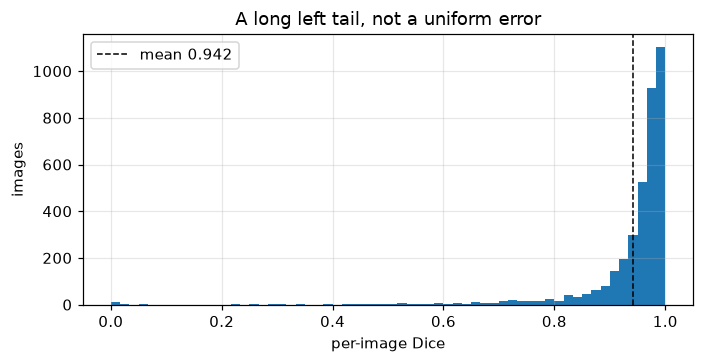

In [20]:
pred = (probs.float() > 0.5)
keep = ~is_boundary
p = pred & keep
t = is_pet & keep
inter = (p & t).sum((1, 2)).float()
per_image = (2 * inter / (p.sum((1, 2)) + t.sum((1, 2))).clamp(min=1).float())

q = np.percentile(per_image.numpy(), [1, 5, 25, 50, 75, 95])
print(f"per-image Dice (boundary='ignore'):  mean {per_image.mean():.4f}")
print(f"  p1 {q[0]:.3f}   p5 {q[1]:.3f}   p25 {q[2]:.3f}   median {q[3]:.3f}   "
      f"p75 {q[4]:.3f}   p95 {q[5]:.3f}")
print(f"  images below 0.50 Dice: {(per_image < 0.5).sum().item():4d}  "
      f"({(per_image < 0.5).float().mean():.2%})")
print(f"  images below 0.80 Dice: {(per_image < 0.8).sum().item():4d}  "
      f"({(per_image < 0.8).float().mean():.2%})")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(per_image.numpy(), bins=60)
ax.axvline(per_image.mean(), c="k", ls="--", lw=1, label=f"mean {per_image.mean():.3f}")
ax.set_xlabel("per-image Dice"); ax.set_ylabel("images"); ax.legend()
ax.set_title("A long left tail, not a uniform error")
plt.tight_layout(); plt.show()

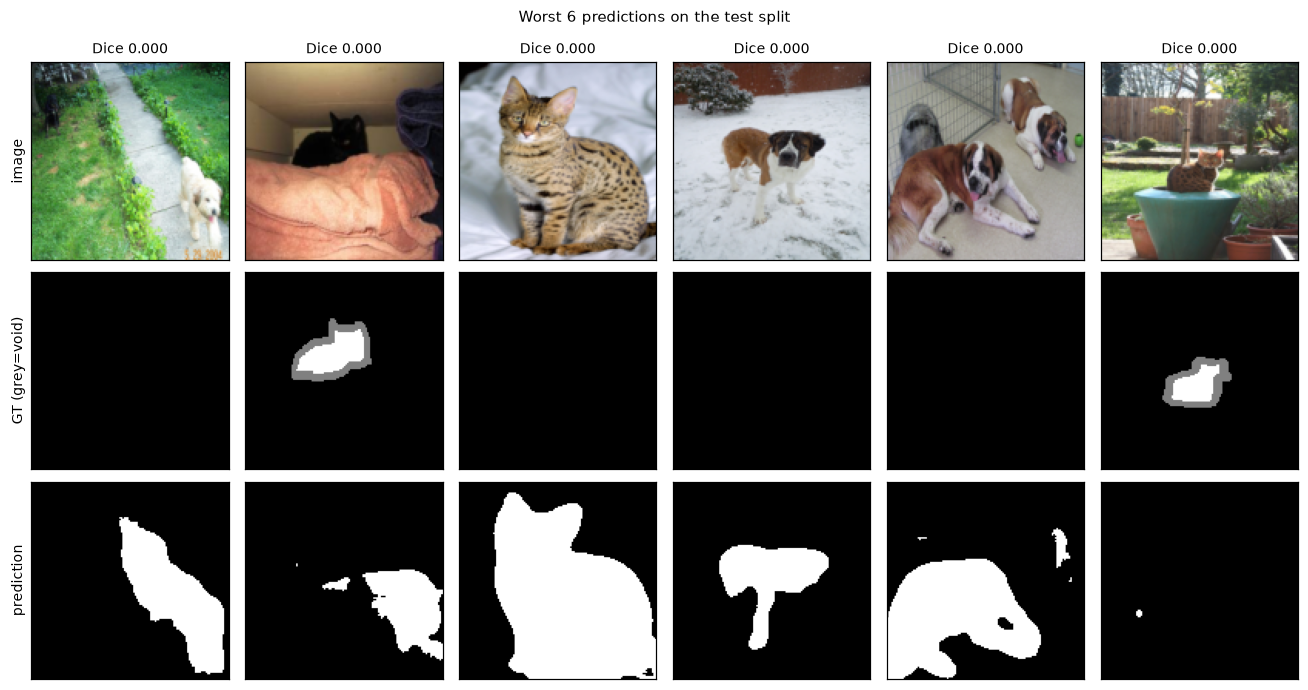

In [21]:
# The worst cases — what a 0.2-Dice prediction actually looks like.
worst = torch.argsort(per_image)[:6]
show_loader = build_loaders(replace(cache_cfg, eval_batch_size=1)).val
dataset = show_loader.dataset

fig, axes = plt.subplots(3, len(worst), figsize=(2.0 * len(worst), 6.4))
for col, idx in enumerate(worst.tolist()):
    img, _ = dataset[idx]
    axes[0, col].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, col].set_title(f"Dice {per_image[idx]:.3f}", fontsize=9)
    gt = np.where(is_boundary[idx].numpy(), 0.5, is_pet[idx].numpy().astype(float))
    axes[1, col].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[2, col].imshow(pred[idx].numpy(), cmap="gray", vmin=0, vmax=1)
    for r in range(3):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([]); axes[r, col].grid(False)
for r, label in enumerate(["image", "GT (grey=void)", "prediction"]):
    axes[r, 0].set_ylabel(label, fontsize=9)
fig.suptitle("Worst 6 predictions on the test split", fontsize=10)
plt.tight_layout(); plt.show()

### 5f. Is the error really on the boundary?

The post-mortem asserted that all the remaining error sits at the object edge.
That is testable: bin every wrong pixel by its distance to the ground-truth
outline. The answer is **half of one and half of the other**, and the distinction
changes which lever to pull.

Error *rate* is strongly boundary-enriched — around 5-7px from the outline it is
roughly 7x the far-field rate. But the far field is 44% of all pixels, so most of
the error *mass* lands far from any edge. Combined with the long left tail in 5e
(1% of images below 0.5 Dice), the picture is not "slightly fuzzy edges
everywhere" but "crisp on most images, wholesale failure on a minority".

That matters: a boundary-weighted loss addresses the enriched rate, but the mass
is in whole-object failures, which is a capacity/prior problem — the pretrained
encoder, not the loss.

In [22]:
from scipy import ndimage

SUBSET_ERR = 600
bins = [0, 1, 2, 3, 5, 8, 12, 20, 10**6]
wrong_by_band = np.zeros(len(bins) - 1)
total_by_band = np.zeros(len(bins) - 1)

for i in range(SUBSET_ERR):
    gt = is_pet[i].numpy()
    valid = ~is_boundary[i].numpy()
    err = (pred[i].numpy() != gt) & valid

    # Distance from the GT outline, measured in both directions.
    dist_out = ndimage.distance_transform_edt(~gt)
    dist_in = ndimage.distance_transform_edt(gt)
    dist = np.where(gt, dist_in, dist_out)

    for b in range(len(bins) - 1):
        band = (dist >= bins[b]) & (dist < bins[b + 1]) & valid
        total_by_band[b] += band.sum()
        wrong_by_band[b] += (err & band).sum()

print(f"over {SUBSET_ERR} images, pixels binned by distance to the GT outline\n")
print(f"{'distance (px)':>14s} {'pixels':>12s} {'% of all':>9s} {'error rate':>11s} {'% of all errors':>16s}")
for b in range(len(bins) - 1):
    lo, hi = bins[b], bins[b + 1]
    label = f">={lo}" if hi > 1000 else f"{lo}-{hi - 1}"
    print(f"{label:>14s} {int(total_by_band[b]):12,d} "
          f"{total_by_band[b] / total_by_band.sum():9.1%} "
          f"{wrong_by_band[b] / max(total_by_band[b], 1):11.2%} "
          f"{wrong_by_band[b] / wrong_by_band.sum():16.1%}")

near = wrong_by_band[:4].sum() / wrong_by_band.sum()
near_px = total_by_band[:4].sum() / total_by_band.sum()
print(f"\nwithin 5px of the outline: {near_px:.1%} of pixels but {near:.1%} of the errors")

over 600 images, pixels binned by distance to the GT outline

 distance (px)       pixels  % of all  error rate  % of all errors
           0-0            0      0.0%       0.00%             0.0%
           1-1      263,928      3.1%       3.31%             2.8%
           2-2      235,106      2.7%       2.85%             2.2%
           3-4      344,448      4.0%       7.13%             7.9%
           5-7      860,794     10.0%      11.42%            31.5%
          8-11    1,157,550     13.4%       4.74%            17.6%
         12-19    1,944,070     22.6%       3.05%            19.0%
          >=20    3,806,103     44.2%       1.57%            19.1%

within 5px of the outline: 9.8% of pixels but 12.8% of the errors


## 6. Benchmark

### Where this lands

| reference point | Dice | IoU |
|---|---|---|
| trivial: all-background | 0.00 | 0.00 |
| trivial: all-foreground | ~0.57 | ~0.42 |
| U-Net from scratch, ~128px (tutorial band) | 0.88 - 0.92 | 0.79 - 0.85 |
| **v1.0, as logged** (`boundary='foreground'`, 128px) | **0.9367** | **0.8964** |
| **v1.0** under `boundary='ignore'` | 0.9418 | 0.9110 |
| **v1.0** under `boundary='ignore'`, threshold tuned on test (leaky) | 0.9628 | - |
| **v1.0** against the *actual* pet outline (`boundary='background'`) | 0.7801 | 0.6872 |
| U-Net + **ImageNet-pretrained encoder**, 224-256px | 0.94 - 0.96 | 0.89 - 0.92 |
| large pretrained transformer (SegFormer-B5 / Mask2Former / DINOv2-L) | ~0.96+ | ~0.92+ |
| SAM zero-shot, box prompt (sanity anchor) | - | ~0.90 |

The reference bands are approximate figures from common practice — Oxford-IIIT Pet
segmentation has no widely-tracked leaderboard.

### Read

Three of the four caveats raised in the v1.0 post-mortem did not survive being
measured. Recorded here because the corrections are the useful part:

* **The label choice was not inflating the score.** The post-mortem predicted
  `boundary='foreground'` was worth +2-4 Dice over `'ignore'`. Measured, it is
  worth **-0.5** — the void band is the hard region, so excluding it *raises* the
  score (5a). The guess had the sign backwards.
* **128px scoring was not flattering the boundary.** Native-resolution scoring
  differs by **under 0.001 Dice** (5d). Immaterial.
* **The error is not all at the edge.** Rate is ~7x enriched near the outline, but
  the far field is 44% of pixels, so most error *mass* is far from any boundary
  (5f). The real signature is 1% of images failing wholesale (5e), not uniformly
  fuzzy edges.
* **What is real, and much bigger than any of the above:** scored against the
  animal's *actual* outline, this model gets **0.7801** Dice, not 0.9367. It
  predicts pet-plus-band because that is what it was trained on. Any comparison to
  a paper that excludes the void band should use 0.9418; any claim that the model
  *delineates pets* should use 0.78.
* The failure mode is still **not overfitting**: train Dice 0.966, 3.0-point gap.
* **Threshold 0.5 is already optimal** for the protocol the model was trained on
  (5b). The large gain available under `ignore` is the threshold absorbing a
  protocol mismatch — peeling off a band the model was taught to predict — not
  free generalization. Real but modest free gain: hflip TTA, +0.33 (5c).

### Next levers (revised by the measurements above)

1. **ImageNet-pretrained encoder** — now the clear top lever, and 5f says why: the
   error mass is whole-object failure, which is a prior/capacity problem.
   (`Resnet50_Encoder` in `models/unet.py`)
2. **Retrain with `boundary="ignore"`** rather than threshold-patching these
   weights (5b) — already the `oxford_pet` preset default.
3. **Train at 224 or 256px** — still a model lever (finer features), though 5d
   removed the measurement-honesty argument for it.
4. **hflip TTA** — +0.33 Dice, free and genuine (5c).
5. **Report `boundary='ignore'` and the 0.78 outline number side by side** — the
   protocol fix that actually matters, unlike native-res scoring.
6. **BCE + soft Dice / boundary weighting** — demoted. 5f shows the boundary
   carries only 13% of the error mass, so this buys less than assumed.
7. Real augmentation, bilinear upsampling, deep supervision, weight EMA.
8. **Not** levers: more epochs, more dropout, more weight decay, native-res eval.

### Next dataset

**Pascal VOC 2012 segmentation** (21 classes, 1,464 / 1,449, or 10,582 with SBD;
mIoU). The canonical next rung: multi-class CE with `ignore_index=255`, severe
class imbalance, per-class mIoU — all machinery this pipeline now has. Then
**Cityscapes** (19 classes at 1024x2048), then **ADE20K** (150 classes).